In [1]:
##### FOR COMPARISON ONLY
##### Creates maps of agricultural capital stock and labor (rasters)
# uses a naive model of country-average intensities for each pixel 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer

In [3]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif")
labor = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif")

production = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif")

country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_capital_labor_raster/country_avg_model"

In [4]:
### Data prep

# align rasters to capital grid
crs = capital.rio.crs

labor = labor.rio.reproject_match(capital)

production = production.rio.reproject_match(capital)

country_boundaries = country_boundaries.to_crs(capital.rio.crs)

# convert units 
capital_million = capital / 1e6


# identify no data countries 
country_boundaries = country_boundaries.merge(has_data, left_on='GID_0', right_on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

In [5]:
##### Calculate intensity rasters 

# calculate intensities
production_masked = production.where(production >= 0.1) 
capital_intensity_USD_per_tonne = capital / production_masked
labor_intensity_thousand_jobs_per_tonne = (labor / production_masked) * 1e3

capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.where(
    np.isfinite(capital_intensity_USD_per_tonne)
)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.where(
    np.isfinite(labor_intensity_thousand_jobs_per_tonne)
)

# Set nodata value  
capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.rio.write_nodata(np.nan)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.rio.write_nodata(np.nan)

# Set CRS 
capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.rio.write_crs(crs)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.rio.write_crs(crs)

# Save
capital_intensity_USD_per_tonne.rio.to_raster(
    f"{cd}/Results/Raster_model/country_avg_model/capital_intensity_USD_per_tonne.tif",
    dtype="float32",
    compress="LZW"
)

labor_intensity_thousand_jobs_per_tonne.rio.to_raster(
    f"{cd}/Results/Raster_model/country_avg_model/labor_intensity_thousand_jobs_per_tonne.tif",
    dtype="float32",
    compress="LZW"
)

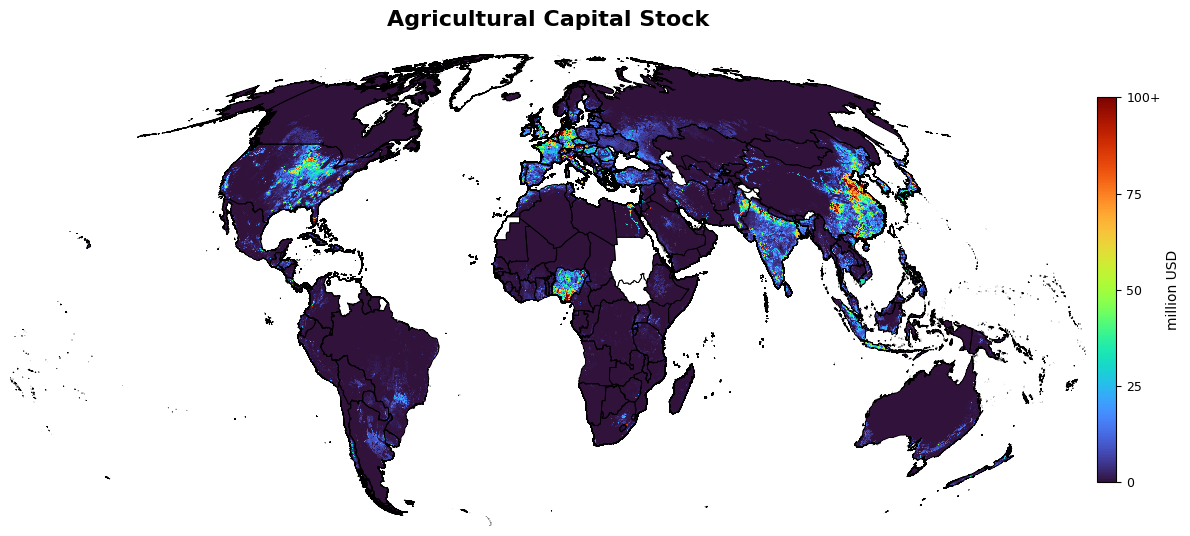

In [7]:
##### Produce global map of capital (mean estimate) 

# Prepare raster
value_plot = capital_million.squeeze()
name = 'capital_stock'

bounds = [0, 25, 50, 75, 100] 
labels = ['0', '25', '50', '75', '100+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (grey fill)
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor="grey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=100,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

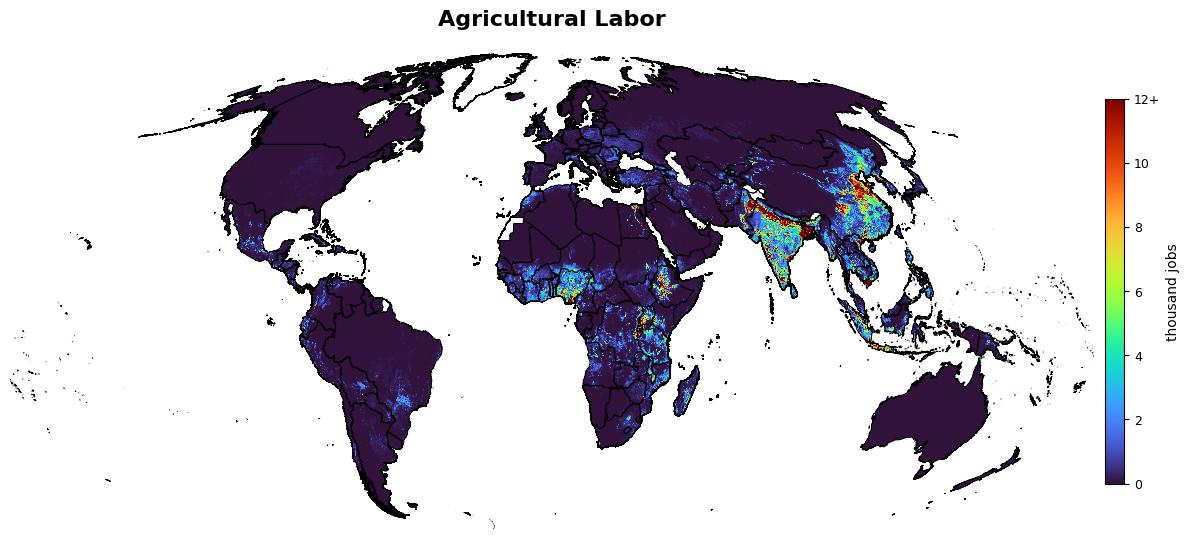

In [8]:
##### Produce global map of labor (mean estimate) 

# Prepare raster
value_plot = labor.squeeze()
name = 'labor'

bounds = [0, 2000, 4000, 6000, 8000, 10000, 12000] 
labels = ['0', '2', '4', '6', '8', '10', '12+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (grey fill)
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor="grey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=12000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Labor", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("thousand jobs", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')